# 03 — IRT Calibration & Adaptive Testing

**Project:** MARS — Multi-Agent Recommender System for Personalized Learning  
**Agent:** DiagnosticAgent (IRT 3PL + CAT)  
**Purpose:** Calibrate item parameters, validate ability estimates,
and generate publication-quality figures for the paper.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr, spearmanr

plt.style.use("seaborn-v0_8-paper")
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "figure.figsize": (8, 5),
    "savefig.bbox": "tight",
})

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

import logging
logging.basicConfig(level=logging.INFO, format="%(name)s | %(message)s")

print("Libraries loaded.")

Libraries loaded.


## 1. Load Data & Calibrate IRT

In [2]:
from data.loader import EdNetLoader
from agents.diagnostic_agent import DiagnosticAgent

loader = EdNetLoader(data_dir="../data/raw")
questions = loader.load_questions()
interactions = loader.load_interactions(sample_users=1000)

print(f"Interactions: {len(interactions):,} rows, {interactions['user_id'].nunique()} users")
print(f"Unique questions in interactions: {interactions['question_id'].nunique()}")

faiss.loader | Loading faiss with AVX2 support.


faiss.loader | Successfully loaded faiss with AVX2 support.


data.loader | Loading questions from ..\data\raw\questions.csv


data.loader | Loaded 13169 questions, 189 unique tags


data.loader | Found 297444 user files in KT2/


...

data.loader | Sampled 1000 / 297444 users (0.3%) — stratified=True


data.loader | Raw KT2 rows: 183166 from 1000 users (load: 3.1s)


data.loader | Aggregating encounters (vectorized)...


data.loader | Final interactions: 51802 rows, 998 users (derive: 0.4s, total: 10.6s)


Interactions: 51,802 rows, 998 users
Unique questions in interactions: 8248


In [3]:
# Calibrate IRT from interactions
diag = DiagnosticAgent()
params = diag.calibrate_from_interactions(
    interactions,
    min_answers_per_q=30,
    max_items=5000,
)

print(f"\nCalibrated {len(params)} items")
print(f"  b (difficulty):      mean={params.b.mean():.3f}, std={params.b.std():.3f}, range=[{params.b.min():.2f}, {params.b.max():.2f}]")
print(f"  a (discrimination):  mean={params.a.mean():.3f}, std={params.a.std():.3f}, range=[{params.a.min():.2f}, {params.a.max():.2f}]")
print(f"  c (guessing):        {params.c[0]:.2f} (fixed)")

2026-04-02 17:42:36 | mars.agent.diagnostic          | INFO    | Building response matrix: 193 questions, 840 users


mars.agent.diagnostic | Building response matrix: 193 questions, 840 users


2026-04-02 17:42:36 | mars.agent.diagnostic          | INFO    | Calibrating IRT 3PL: 840 students x 193 items


mars.agent.diagnostic | Calibrating IRT 3PL: 840 students x 193 items


2026-04-02 17:42:37 | mars.agent.diagnostic          | INFO    | IRT calibrated: b=[-2.71, 2.60], a=[0.20, 1.32], c=0.25


mars.agent.diagnostic | IRT calibrated: b=[-2.71, 2.60], a=[0.20, 1.32], c=0.25



Calibrated 193 items
  b (difficulty):      mean=0.081, std=0.831, range=[-2.71, 2.60]
  a (discrimination):  mean=0.397, std=0.257, range=[0.20, 1.32]
  c (guessing):        0.25 (fixed)


## 2. Difficulty Distribution

matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


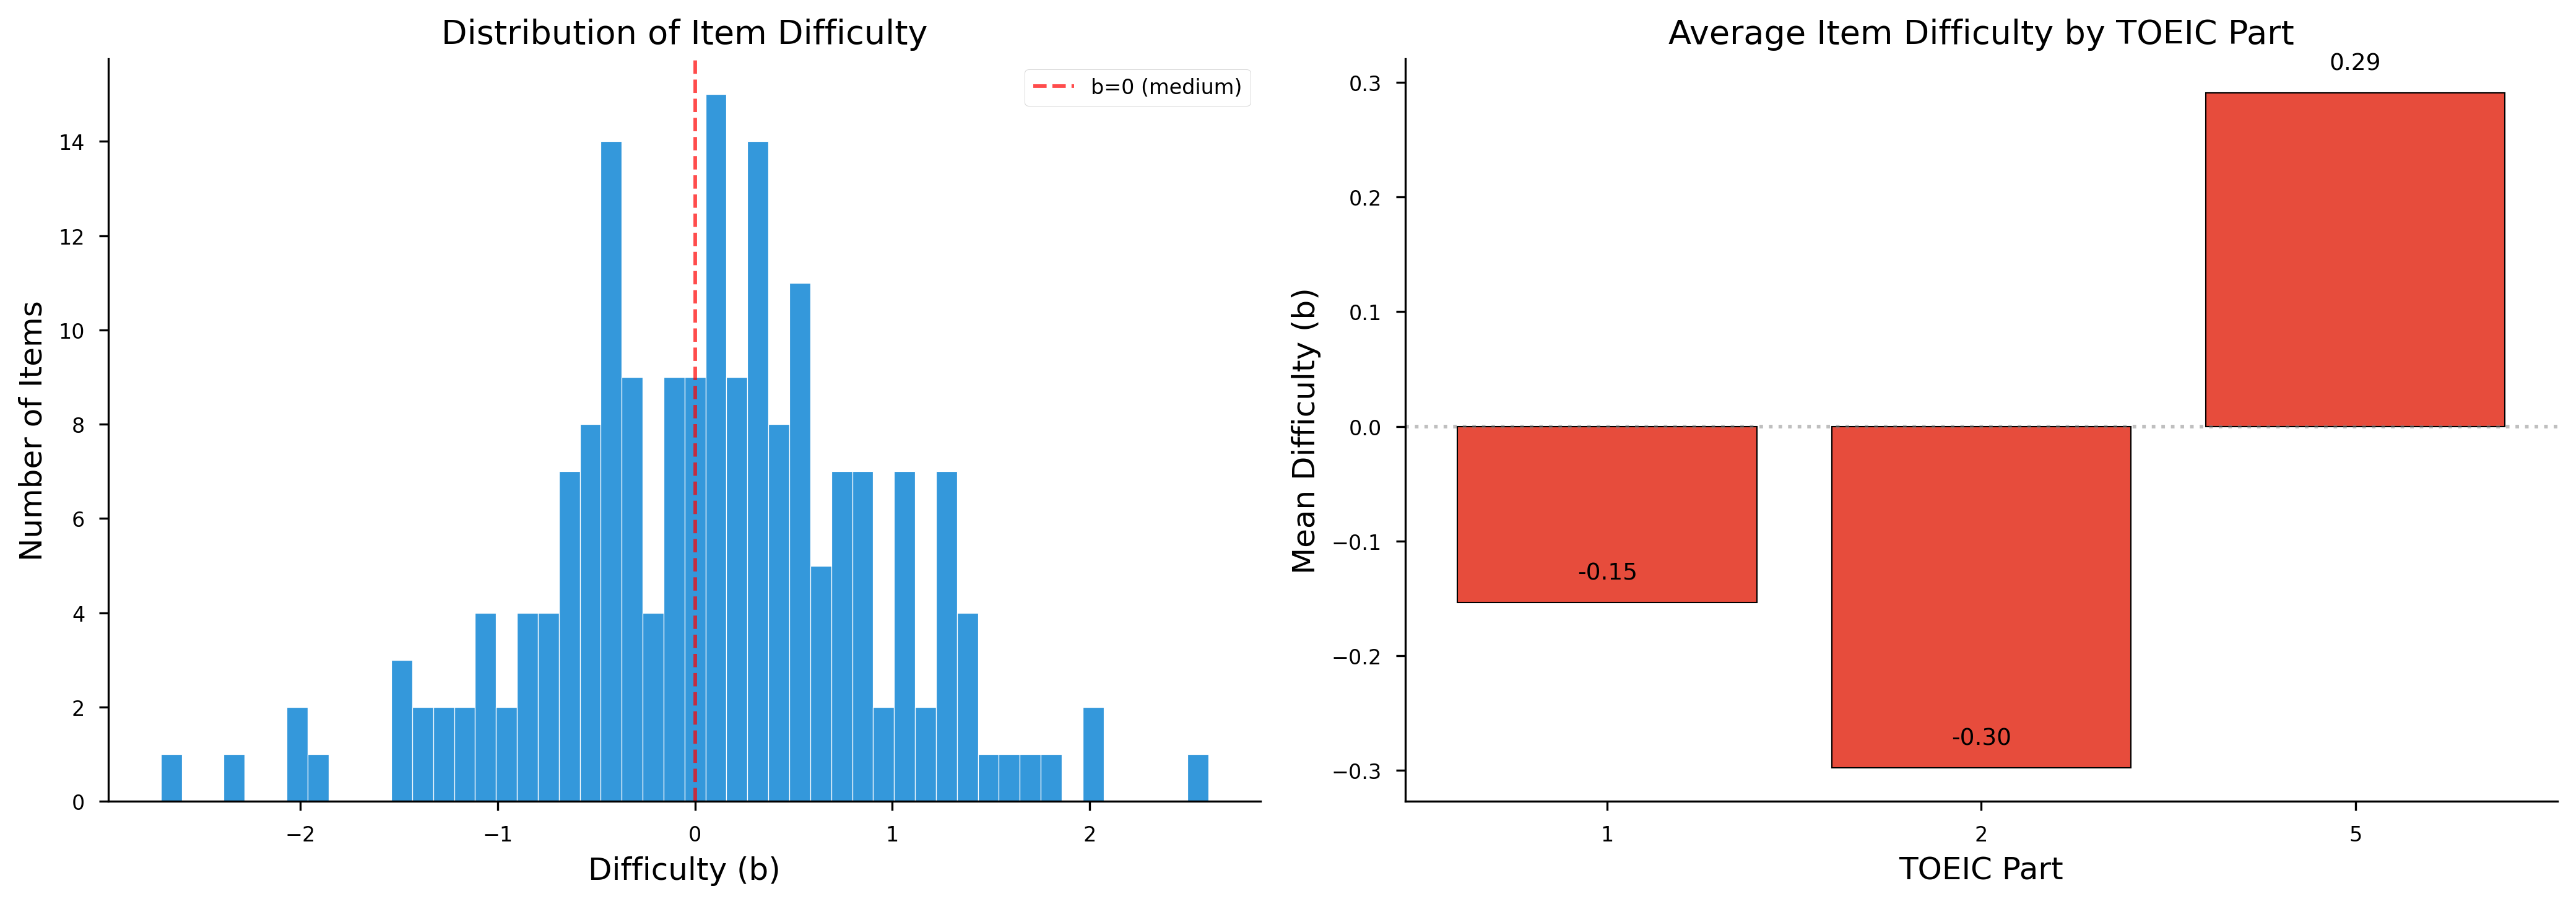

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Difficulty histogram
axes[0].hist(params.b, bins=50, color="#3498db", edgecolor="white", linewidth=0.3)
axes[0].axvline(0, color="red", linestyle="--", alpha=0.7, label="b=0 (medium)")
axes[0].set_xlabel("Difficulty (b)")
axes[0].set_ylabel("Number of Items")
axes[0].set_title("Distribution of Item Difficulty")
axes[0].legend()

# Difficulty by part
part_data = pd.DataFrame({"b": params.b, "part": params.part_ids})
part_means = part_data.groupby("part")["b"].mean().sort_index()
bars = axes[1].bar(part_means.index.astype(str), part_means.values,
                    color="#e74c3c", edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, part_means.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f"{val:.2f}", ha="center", fontsize=9)
axes[1].set_xlabel("TOEIC Part")
axes[1].set_ylabel("Mean Difficulty (b)")
axes[1].set_title("Average Item Difficulty by TOEIC Part")
axes[1].axhline(0, color="gray", linestyle=":", alpha=0.5)

for ax in axes:
    sns.despine(ax=ax)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "fig_irt_difficulty.png")
plt.show()

## 3. Discrimination Distribution

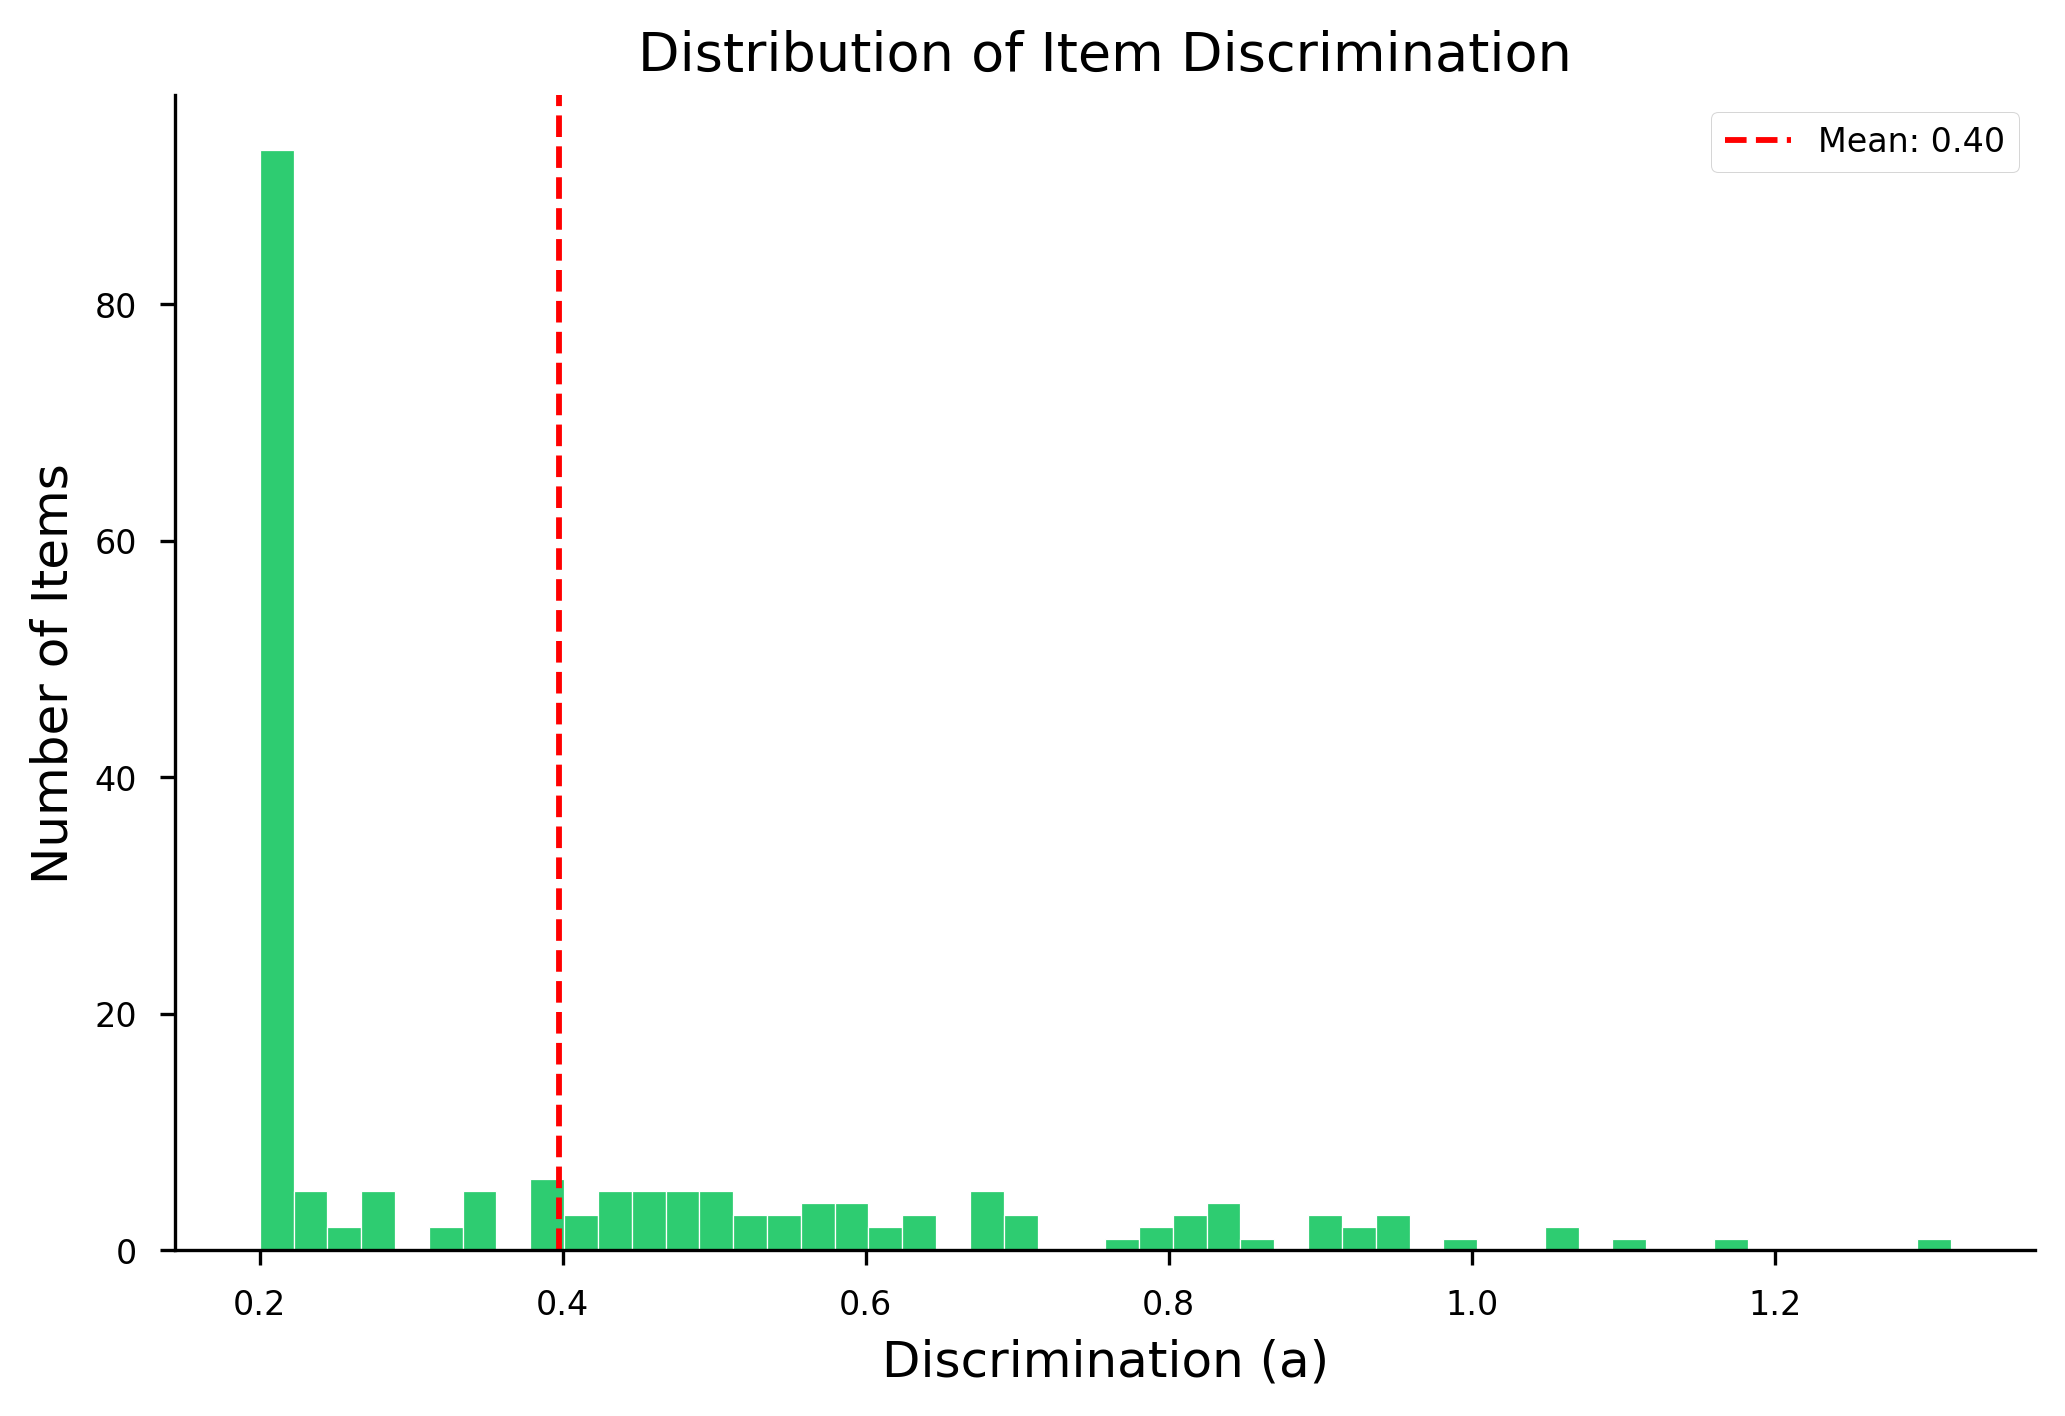

Low discrimination (a < 0.5): 138 items
High discrimination (a > 1.5): 0 items


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(params.a, bins=50, color="#2ecc71", edgecolor="white", linewidth=0.3)
ax.axvline(params.a.mean(), color="red", linestyle="--",
           label=f"Mean: {params.a.mean():.2f}")
ax.set_xlabel("Discrimination (a)")
ax.set_ylabel("Number of Items")
ax.set_title("Distribution of Item Discrimination")
ax.legend()
sns.despine()

fig.savefig(RESULTS_DIR / "fig_irt_discrimination.png")
plt.show()

# Stats
print(f"Low discrimination (a < 0.5): {(params.a < 0.5).sum()} items")
print(f"High discrimination (a > 1.5): {(params.a > 1.5).sum()} items")

## 4. Item Characteristic Curves (ICC)

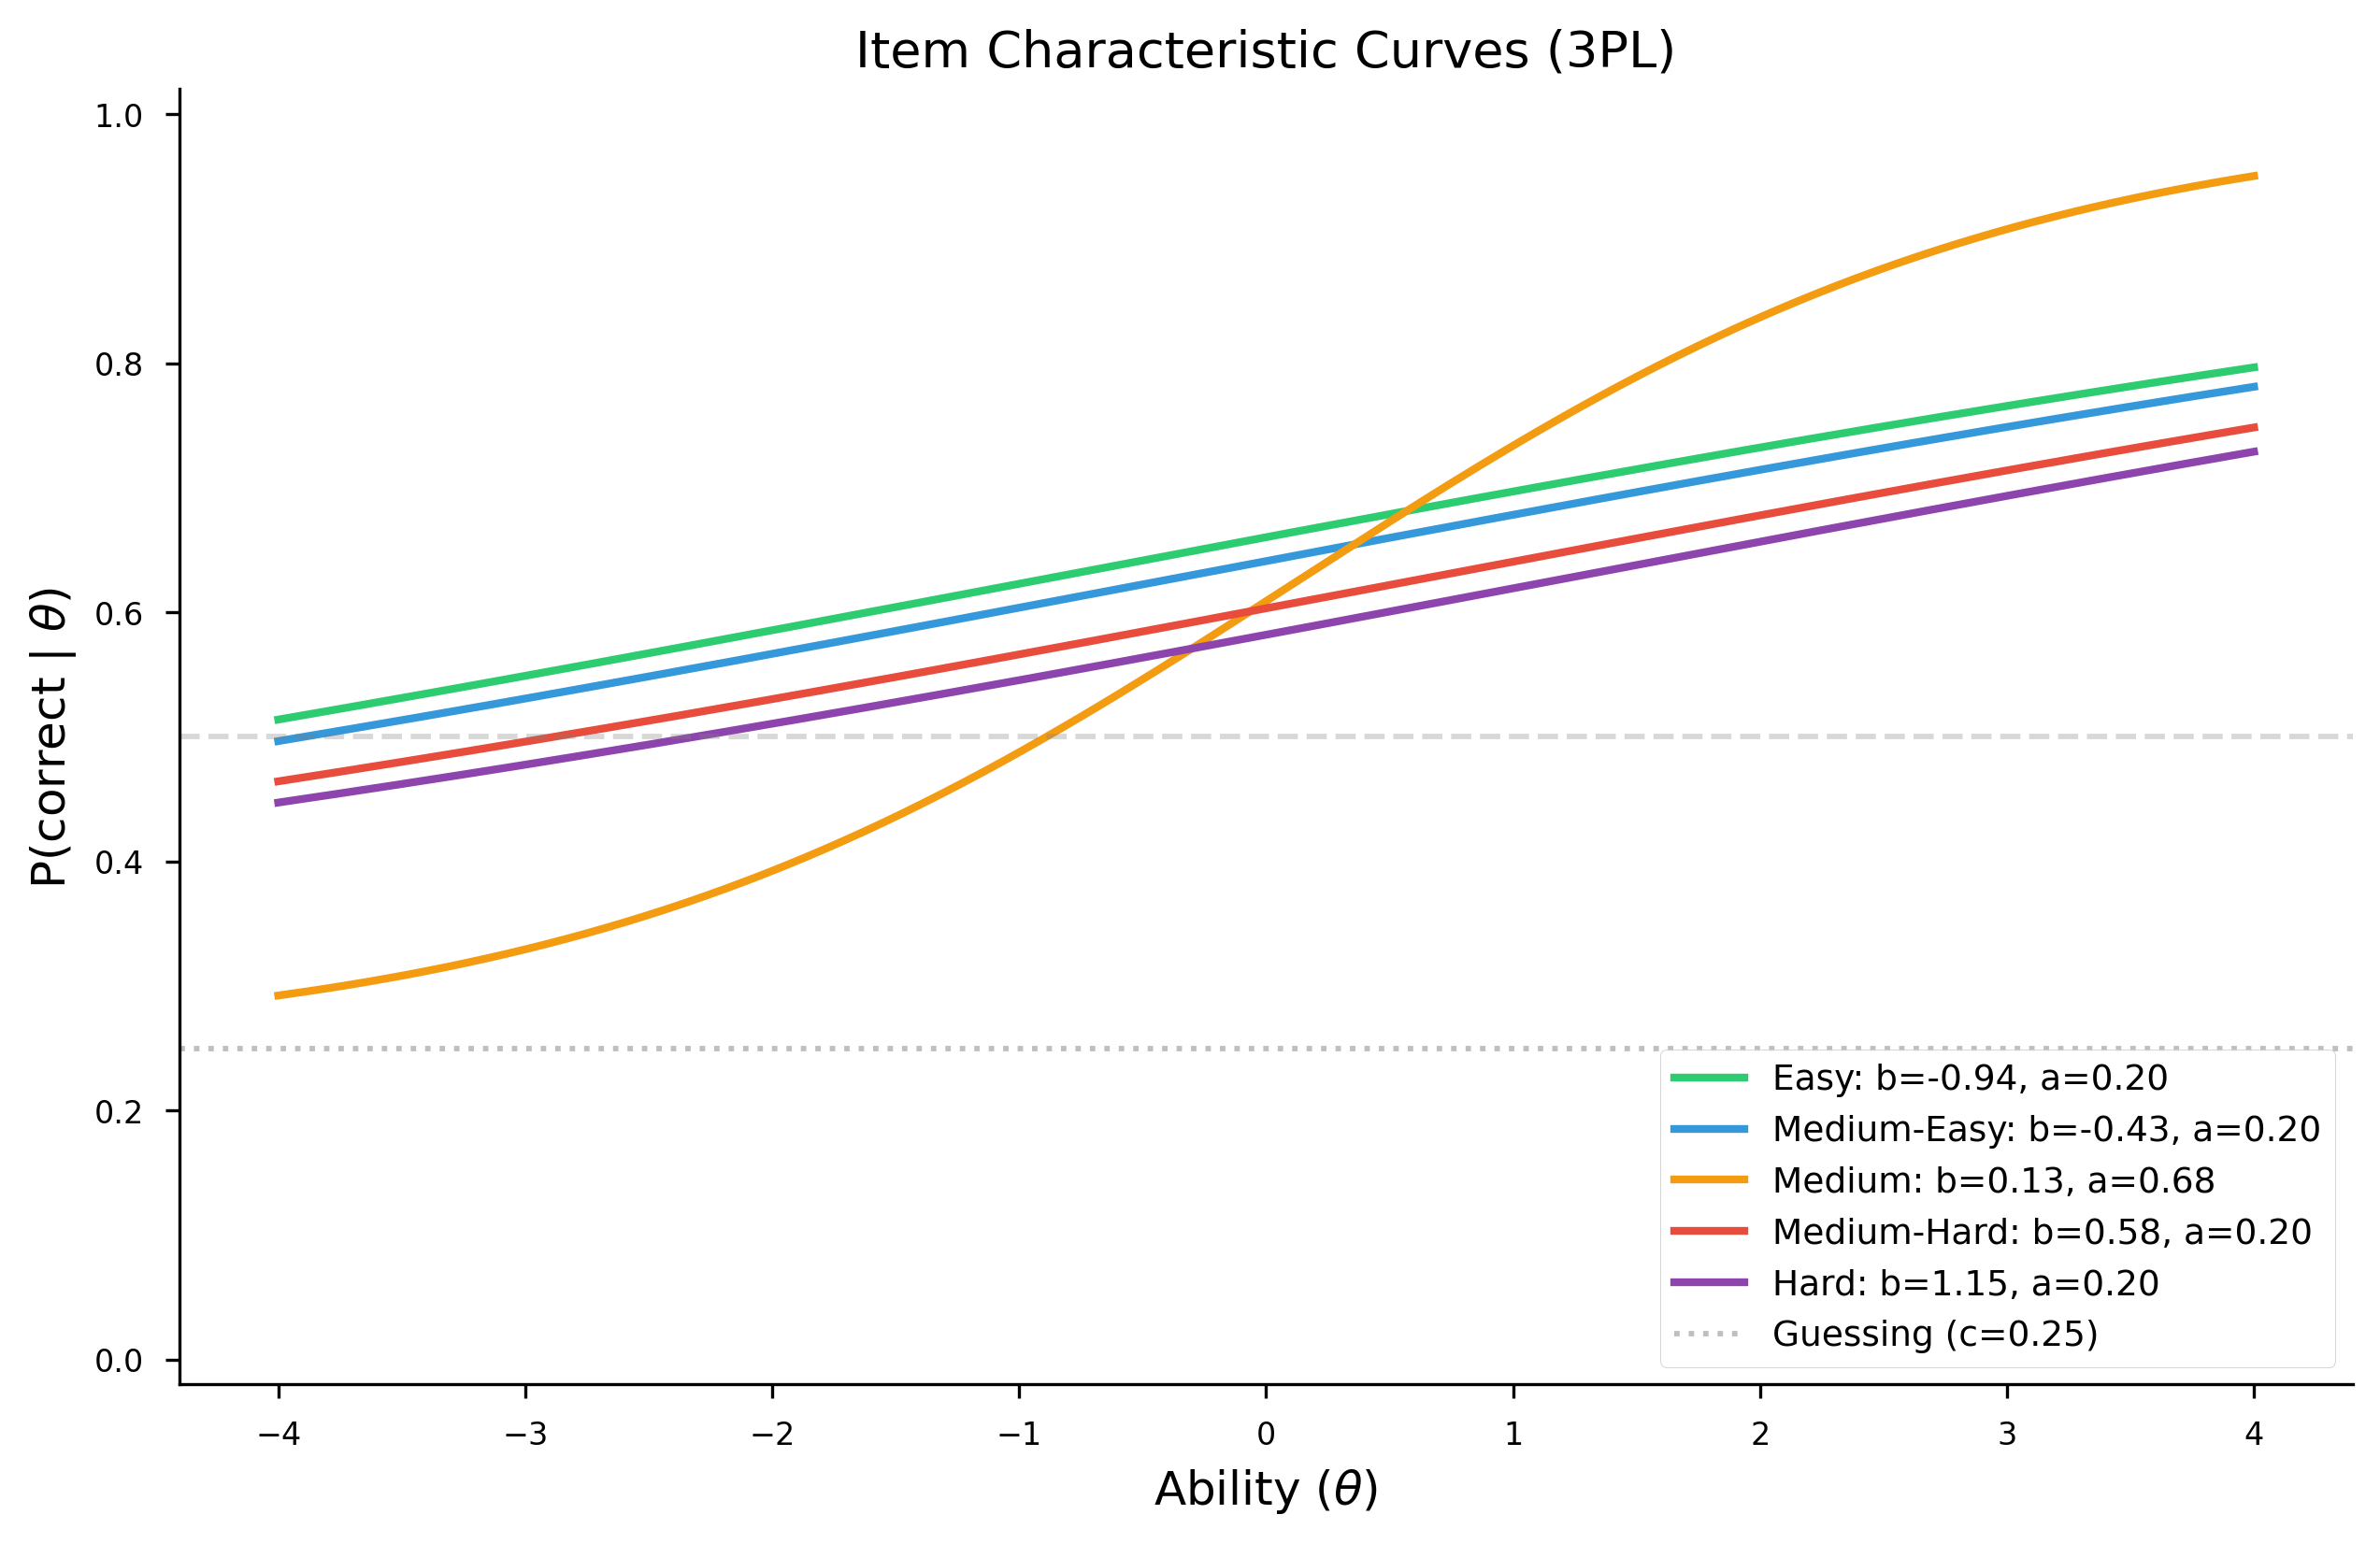

In [6]:
thetas = np.linspace(-4, 4, 200)

# Select 5 representative items: easy, medium-easy, medium, medium-hard, hard
b_sorted = np.argsort(params.b)
n = len(params)
sample_indices = [
    b_sorted[n // 10],          # easy
    b_sorted[n // 4],           # medium-easy
    b_sorted[n // 2],           # medium
    b_sorted[3 * n // 4],       # medium-hard
    b_sorted[9 * n // 10],      # hard
]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#2ecc71", "#3498db", "#f39c12", "#e74c3c", "#8e44ad"]
labels = ["Easy", "Medium-Easy", "Medium", "Medium-Hard", "Hard"]

for idx, color, label in zip(sample_indices, colors, labels):
    icc = diag.icc_curve(idx, thetas)
    qid = params.question_ids[idx]
    ax.plot(thetas, icc, color=color, linewidth=2,
            label=f"{label}: b={params.b[idx]:.2f}, a={params.a[idx]:.2f}")

ax.axhline(0.25, color="gray", linestyle=":", alpha=0.5, label="Guessing (c=0.25)")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.3)
ax.set_xlabel(r"Ability ($\theta$)")
ax.set_ylabel(r"P(correct | $\theta$)")
ax.set_title("Item Characteristic Curves (3PL)")
ax.legend(fontsize=9, loc="lower right")
ax.set_ylim(-0.02, 1.02)
sns.despine()

fig.savefig(RESULTS_DIR / "fig_icc_curves.png")
plt.show()

## 5. Test Information Function

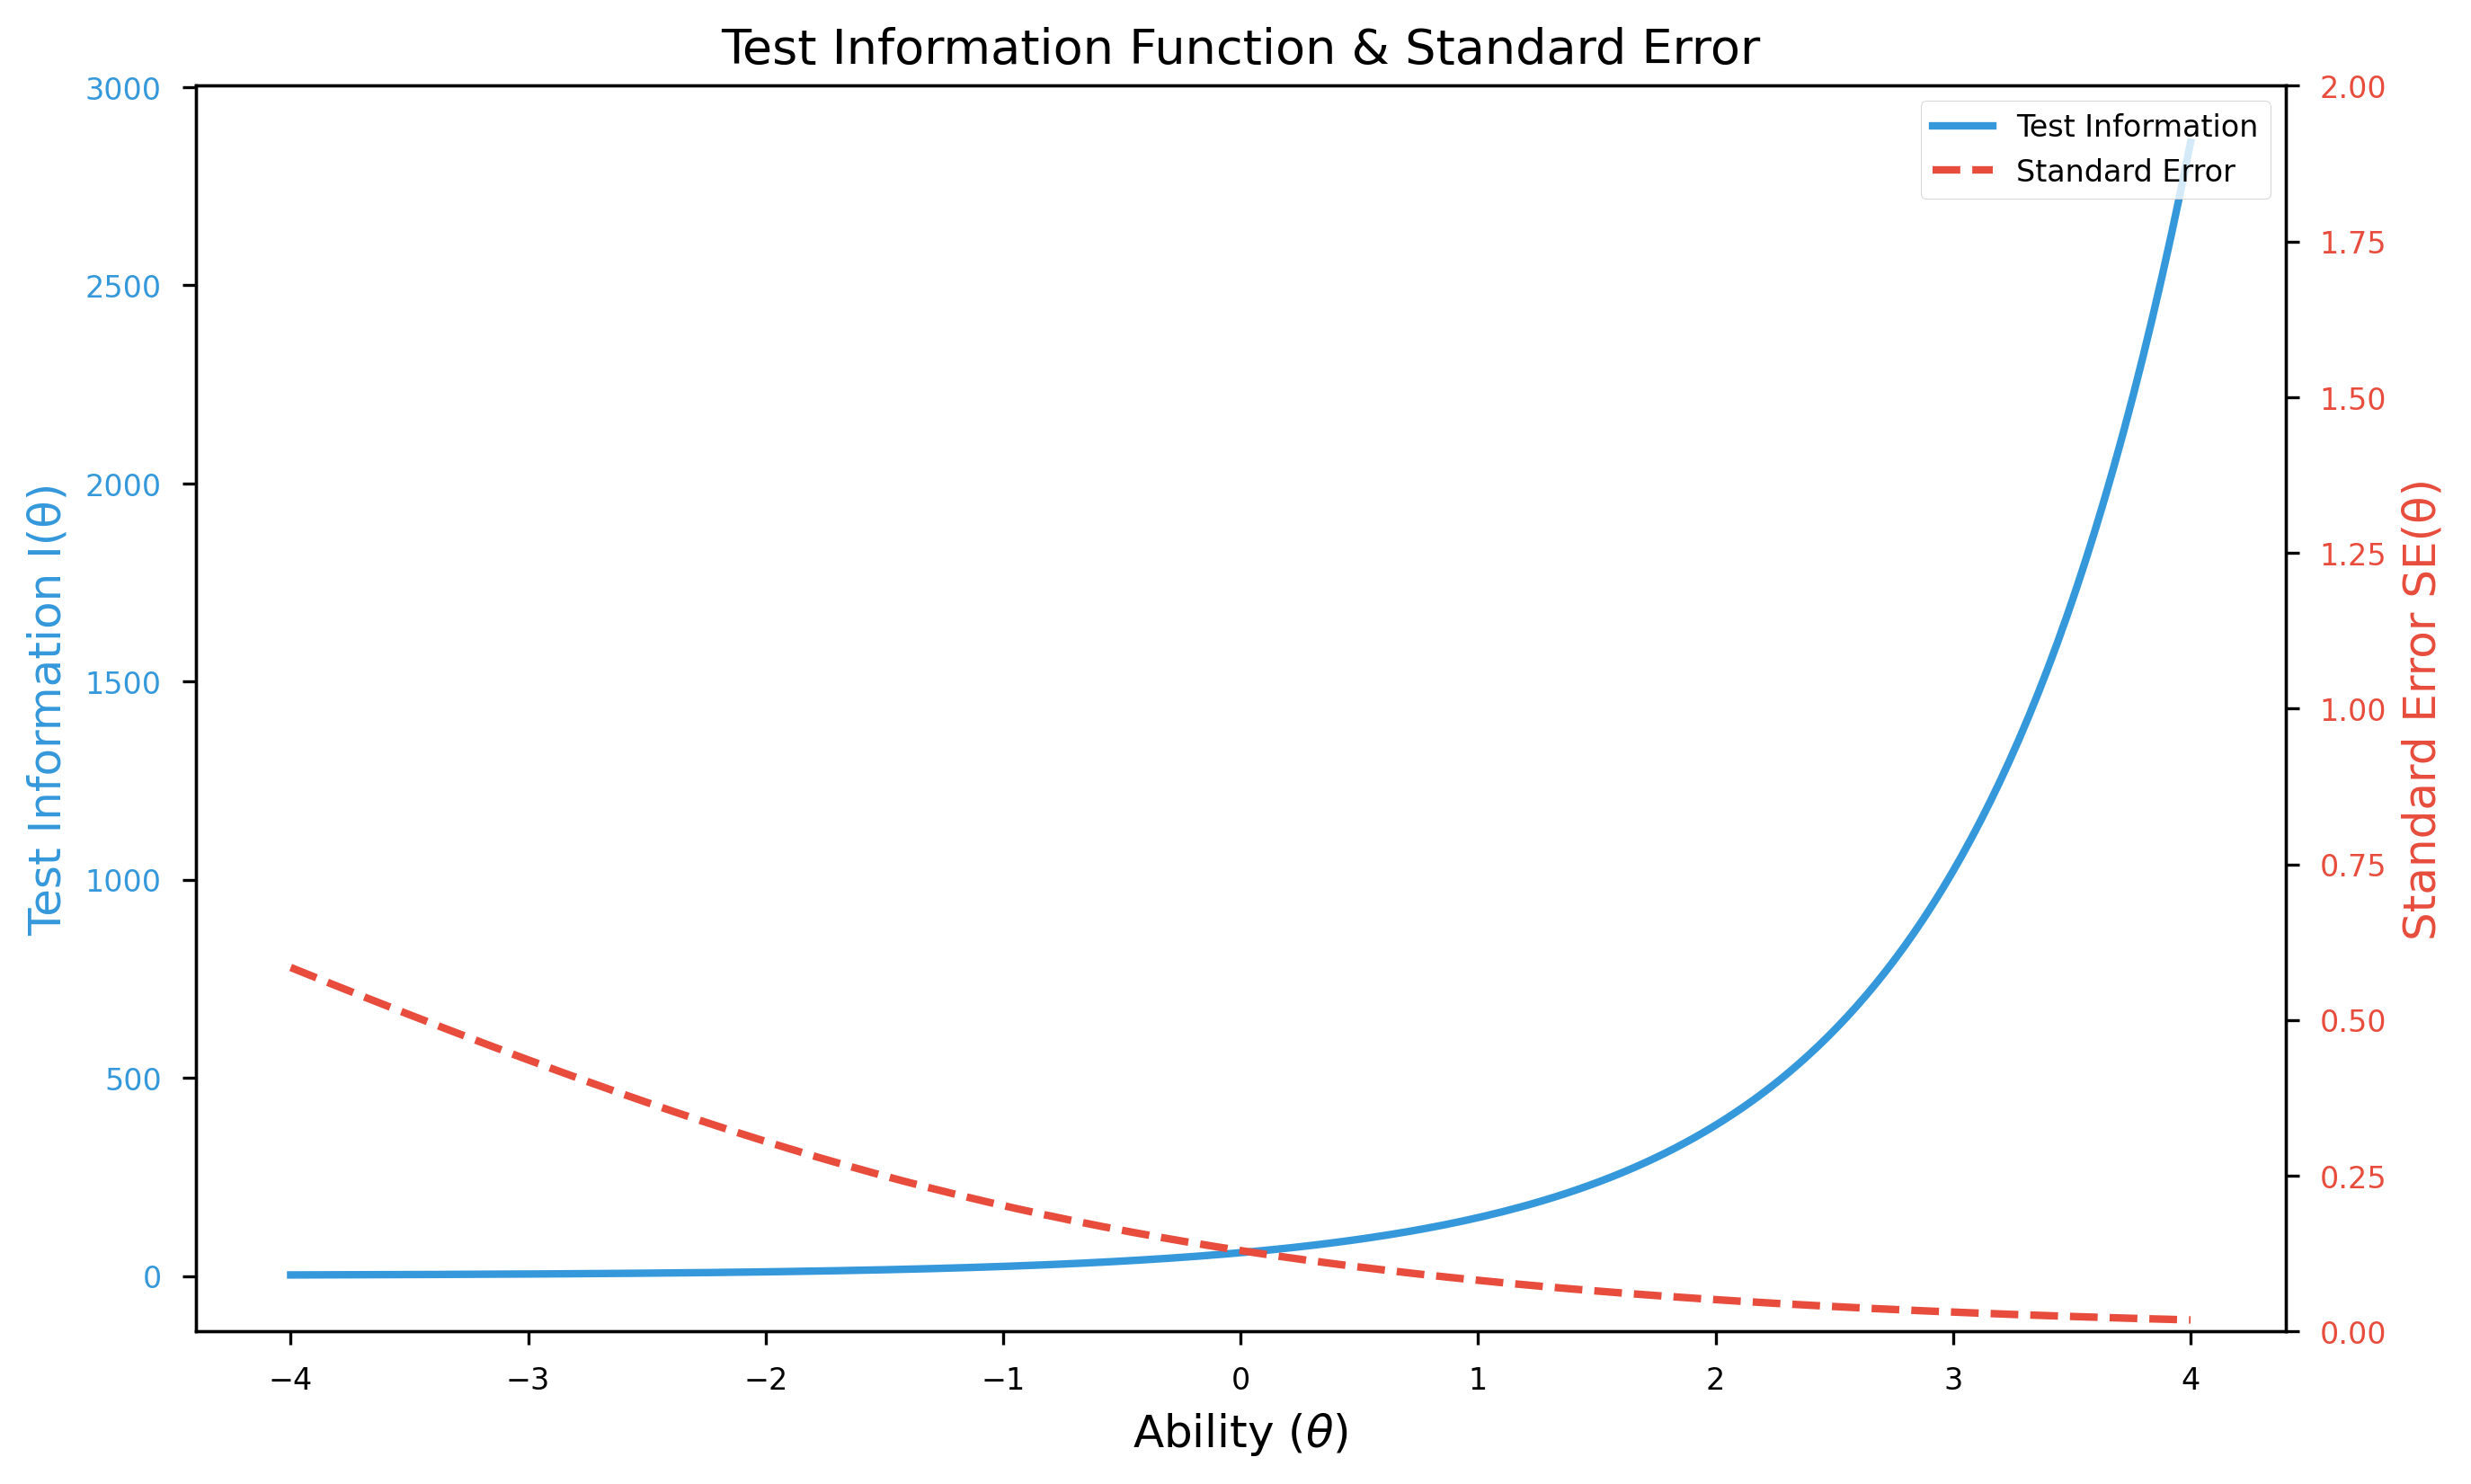

Peak information at theta=4.00, I=2860.8
SE at peak: 0.0187


In [7]:
tif = diag.test_information_function(thetas)
se_curve = 1.0 / np.sqrt(np.clip(tif, 1e-10, None))

fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = "#3498db"
ax1.plot(thetas, tif, color=color1, linewidth=2, label="Test Information")
ax1.set_xlabel(r"Ability ($\theta$)")
ax1.set_ylabel("Test Information I(\u03b8)", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
color2 = "#e74c3c"
ax2.plot(thetas, se_curve, color=color2, linewidth=2, linestyle="--", label="Standard Error")
ax2.set_ylabel("Standard Error SE(\u03b8)", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)
ax2.set_ylim(0, 2)

ax1.set_title("Test Information Function & Standard Error")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

fig.savefig(RESULTS_DIR / "fig_test_information.png")
plt.show()

# Peak information
peak_theta = thetas[np.argmax(tif)]
print(f"Peak information at theta={peak_theta:.2f}, I={tif.max():.1f}")
print(f"SE at peak: {se_curve[np.argmax(tif)]:.4f}")

## 6. Estimate Abilities & Validate Against Accuracy

In [8]:
# Estimate theta for each user from their responses
user_ids = interactions["user_id"].unique()
user_stats = []

for uid in user_ids:
    user_df = interactions[interactions["user_id"] == uid]
    result = diag.run_assessment(uid, user_df)
    actual_acc = user_df["correct"].mean()
    user_stats.append({
        "user_id": uid,
        "theta": result["ability"],
        "se": result["se"],
        "accuracy": actual_acc,
        "n_responses": len(user_df),
    })

user_df = pd.DataFrame(user_stats)
print(f"Estimated abilities for {len(user_df)} users")
print(user_df[["theta", "se", "accuracy"]].describe().round(3))

2026-04-02 17:42:40 | mars.agent.diagnostic          | INFO    | Assessment for u10219: theta=-2.481, SE=0.446 from 115 responses


mars.agent.diagnostic | Assessment for u10219: theta=-2.481, SE=0.446 from 115 responses


2026-04-02 17:42:40 | mars.agent.diagnostic          | INFO    | Assessment for u10530: theta=-1.427, SE=2.244 from 7 responses


mars.agent.diagnostic | Assessment for u10530: theta=-1.427, SE=2.244 from 7 responses


2026-04-02 17:42:40 | mars.agent.diagnostic          | INFO    | Assessment for u11039: theta=-0.109, SE=0.559 from 13 responses


...

2026-04-02 17:42:45 | mars.agent.diagnostic          | INFO    | Assessment for u9165: theta=-0.972, SE=0.267 from 90 responses


mars.agent.diagnostic | Assessment for u9165: theta=-0.972, SE=0.267 from 90 responses


2026-04-02 17:42:45 | mars.agent.diagnostic          | INFO    | Assessment for u9189: theta=-1.434, SE=0.720 from 32 responses


mars.agent.diagnostic | Assessment for u9189: theta=-1.434, SE=0.720 from 32 responses


Estimated abilities for 998 users
         theta       se  accuracy
count  998.000  998.000   998.000
mean    -0.624  160.199     0.502
std      1.851  365.338     0.219
min     -4.000    0.094     0.000
25%     -2.140    1.000     0.364
50%     -0.477    1.000     0.500
75%      0.039    2.317     0.659
max      3.392  999.000     1.000


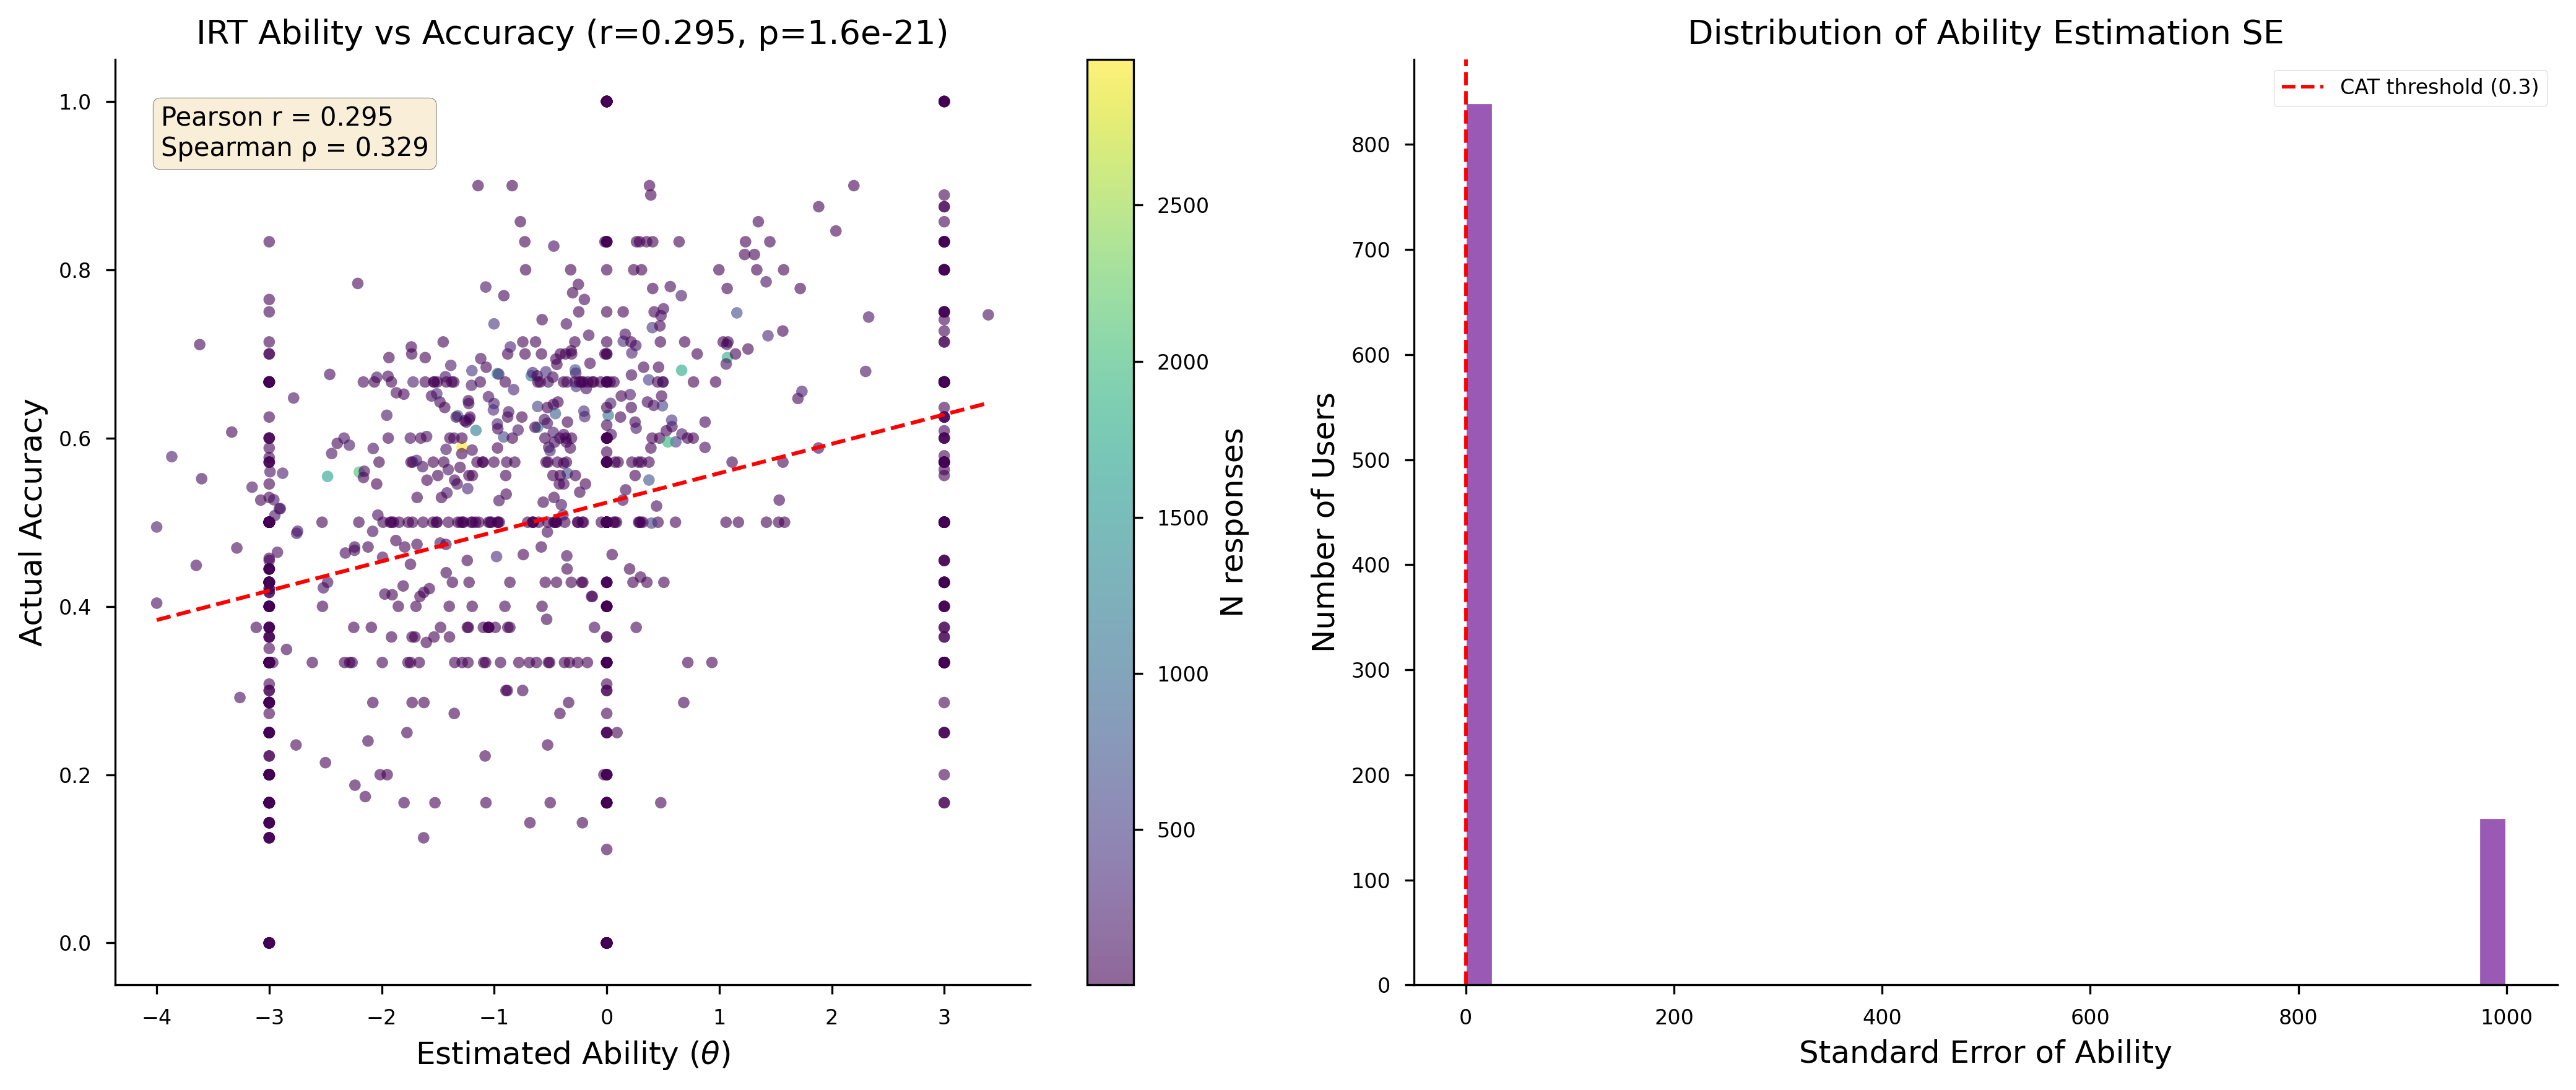

In [9]:
# Scatter: theta vs actual accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Theta vs Accuracy
ax = axes[0]
sc = ax.scatter(user_df["theta"], user_df["accuracy"],
                c=user_df["n_responses"], cmap="viridis",
                s=20, alpha=0.6, edgecolors="none")
plt.colorbar(sc, ax=ax, label="N responses")

# Correlation
r_pearson, p_val = pearsonr(user_df["theta"], user_df["accuracy"])
r_spearman, _ = spearmanr(user_df["theta"], user_df["accuracy"])

# Fit line
z = np.polyfit(user_df["theta"], user_df["accuracy"], 1)
poly = np.poly1d(z)
x_line = np.linspace(user_df["theta"].min(), user_df["theta"].max(), 100)
ax.plot(x_line, poly(x_line), "r--", linewidth=1.5)

ax.set_xlabel(r"Estimated Ability ($\theta$)")
ax.set_ylabel("Actual Accuracy")
ax.set_title(f"IRT Ability vs Accuracy (r={r_pearson:.3f}, p={p_val:.1e})")
ax.text(0.05, 0.95, f"Pearson r = {r_pearson:.3f}\nSpearman \u03c1 = {r_spearman:.3f}",
        transform=ax.transAxes, va="top", fontsize=10,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

# SE distribution
ax = axes[1]
ax.hist(user_df["se"], bins=40, color="#9b59b6", edgecolor="white", linewidth=0.3)
ax.axvline(0.3, color="red", linestyle="--", label="CAT threshold (0.3)")
ax.set_xlabel("Standard Error of Ability")
ax.set_ylabel("Number of Users")
ax.set_title("Distribution of Ability Estimation SE")
ax.legend()

for ax in axes:
    sns.despine(ax=ax)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "fig_theta_vs_accuracy.png")
plt.show()

## 7. CAT Simulation

2026-04-02 17:42:46 | mars.agent.diagnostic          | INFO    | CAT early stop at item 5: SE=0.238 < 0.300


mars.agent.diagnostic | CAT early stop at item 5: SE=0.238 < 0.300


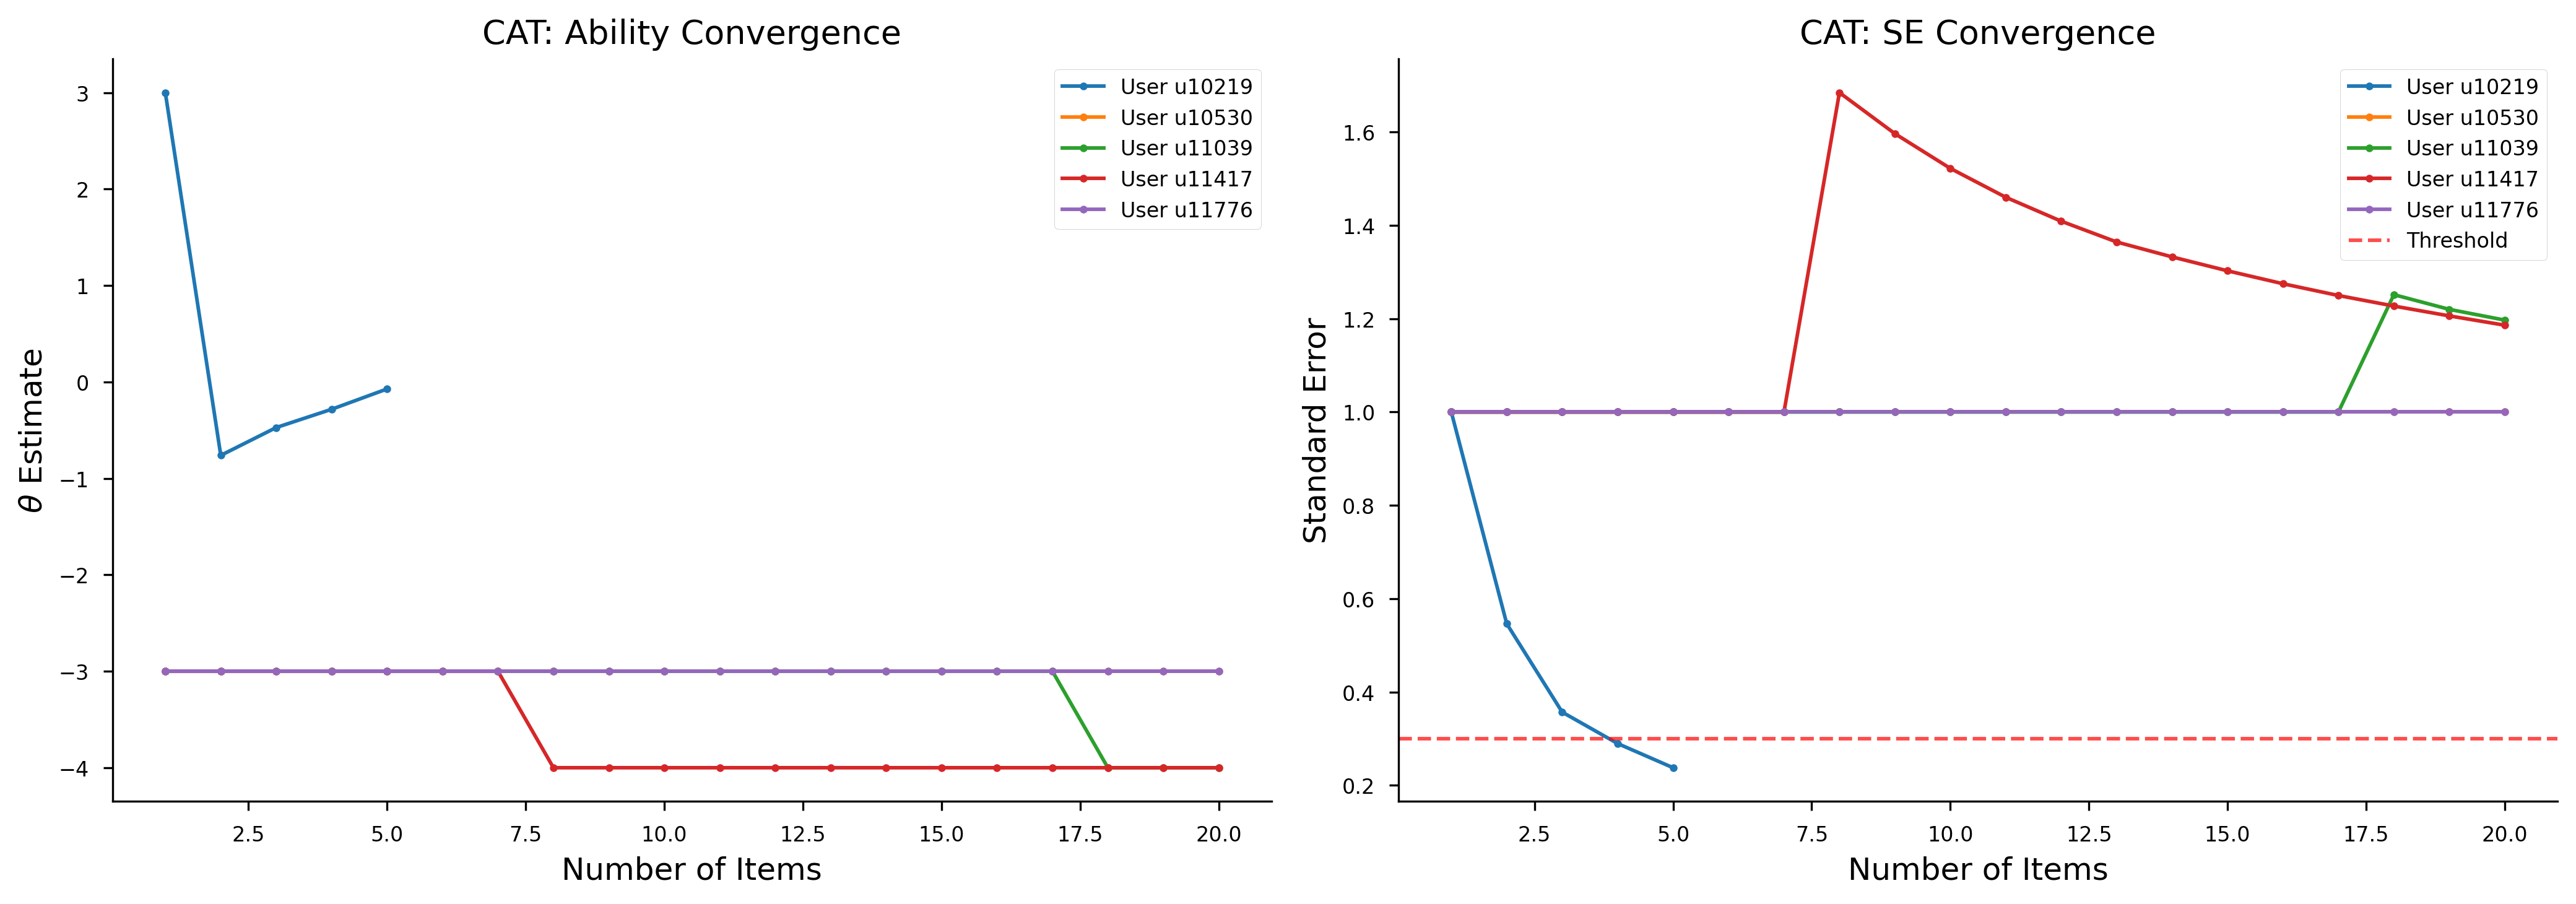

Average items to convergence: 17.0


In [10]:
# Simulate CAT for a few users
sample_users = user_ids[:5]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

convergence_items = []

for uid in sample_users:
    user_interactions = interactions[interactions["user_id"] == uid]
    # Build simulated response dict
    sim_resp = {}
    for _, row in user_interactions.iterrows():
        qid = str(row["question_id"])
        sim_resp[qid] = bool(row["correct"])

    cat_result = diag.run_cat_session(
        user_id=f"cat_{uid}",
        simulated_responses=sim_resp,
        max_items=20,
    )

    # Plot theta convergence
    steps = range(1, len(cat_result["responses"]) + 1)
    thetas_seq = [r["theta_after"] for r in cat_result["responses"]]
    se_seq = [r["se_after"] for r in cat_result["responses"]]

    axes[0].plot(steps, thetas_seq, marker="o", markersize=3, label=f"User {uid}")
    axes[1].plot(steps, se_seq, marker="o", markersize=3, label=f"User {uid}")
    convergence_items.append(cat_result["n_items"])

axes[0].set_xlabel("Number of Items")
axes[0].set_ylabel(r"$\theta$ Estimate")
axes[0].set_title("CAT: Ability Convergence")
axes[0].legend(fontsize=8)

axes[1].axhline(0.3, color="red", linestyle="--", alpha=0.7, label="Threshold")
axes[1].set_xlabel("Number of Items")
axes[1].set_ylabel("Standard Error")
axes[1].set_title("CAT: SE Convergence")
axes[1].legend(fontsize=8)

for ax in axes:
    sns.despine(ax=ax)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "fig_cat_convergence.png")
plt.show()

print(f"Average items to convergence: {np.mean(convergence_items):.1f}")

## 8. Diagnostic Test Demo

In [11]:
# Run diagnostic for a sample user
uid = user_ids[0]
user_responses = interactions[interactions["user_id"] == uid]
sim_resp = {str(r["question_id"]): bool(r["correct"]) for _, r in user_responses.iterrows()}

diag_result = diag.run_diagnostic(f"demo_{uid}", simulated_responses=sim_resp)

print(f"Diagnostic Result for user {uid}:")
print(f"  Ability (theta): {diag_result['ability']}")
print(f"  SE: {diag_result['se']}")
print(f"  Items: {diag_result['n_questions']}")
print(f"  Parts covered: {diag_result['parts_covered']}")
print(f"\nPer-item details:")
for r in diag_result["responses"]:
    mark = "correct" if r["correct"] else "wrong"
    print(f"  {r['question_id']:>8s}  part={r['part_id']}  b={r['difficulty']:+.2f}  {mark}")

2026-04-02 17:42:46 | mars.agent.diagnostic          | INFO    | Diagnostic for demo_u10219: theta=-1.087, SE=0.408, 7 items, parts=[1, 2, 5]


mars.agent.diagnostic | Diagnostic for demo_u10219: theta=-1.087, SE=0.408, 7 items, parts=[1, 2, 5]


Diagnostic Result for user u10219:
  Ability (theta): -1.0867
  SE: 0.4077
  Items: 7
  Parts covered: [1, 2, 5]

Per-item details:
       188  part=1  b=-2.71  wrong
      8154  part=1  b=-2.03  correct
       373  part=2  b=-1.25  correct
       997  part=2  b=-1.46  correct
      6168  part=5  b=-0.43  wrong
      9580  part=5  b=-0.84  wrong
       600  part=2  b=-1.53  correct


In [12]:
print("\n=== IRT Calibration & CAT Complete ===")
print(f"Items calibrated: {len(params)}")
print(f"Users assessed: {len(user_df)}")
print(f"Theta-accuracy correlation: r={r_pearson:.3f}")
print(f"Figures saved to: {RESULTS_DIR.resolve()}")


=== IRT Calibration & CAT Complete ===
Items calibrated: 193
Users assessed: 998
Theta-accuracy correlation: r=0.295
Figures saved to: C:\Users\user\Documents\Diser\система\ednet-mars\results


## Item Fit Analysis (infit/outfit MNSQ)

Item Fit Analysis (193 items):
  Infit acceptable (0.5-1.5):  99.5%
  Outfit acceptable (0.5-1.5): 98.4%
  Mean infit:  0.956 +/- 0.134
  Mean outfit: 0.944 +/- 0.152
  Misfit items: 3 / 193
  Worst outfit: 1.188 (item 6525)
  Worst infit:  1.186 (item 6525)

Person Reliability: 0.000
  Interpretation: Poor (< 0.7)


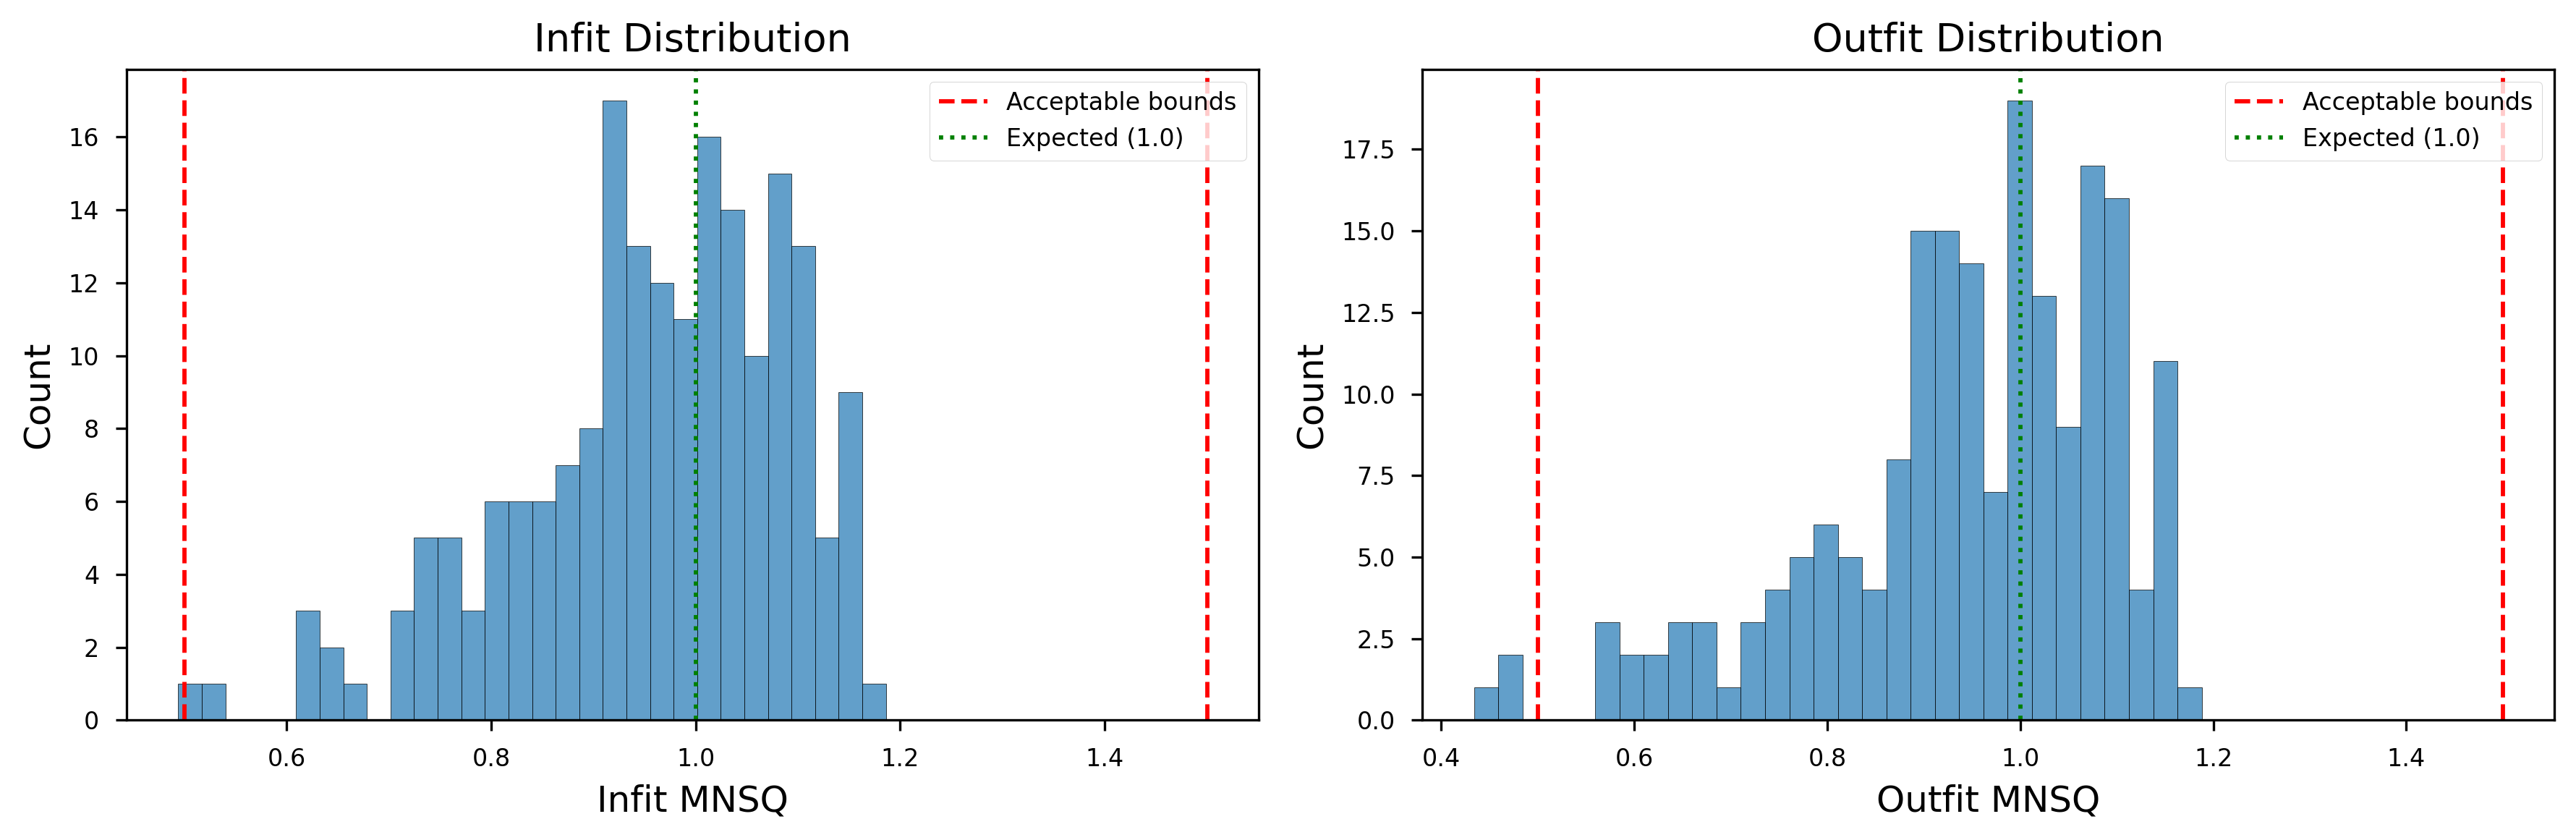

Saved: ..\results\fig_irt_item_fit.png


In [13]:
# === Item Fit Analysis (infit/outfit MNSQ) ===
# Standard IRT validation: shows how well the model fits the data.
# Acceptable range: 0.5 <= MNSQ <= 1.5 (Wilson, 2005)

def compute_item_fit(responses_df, user_df, params):
    """
    Compute infit and outfit MNSQ for each item.

    responses_df: DataFrame with columns [user_id, question_id, correct]
    user_df: DataFrame with columns [user_id, theta]
    params: IRT params object with .a, .b, .c, .question_ids
    """
    # Build lookup dicts from params
    theta_dict = dict(zip(user_df["user_id"].astype(str), user_df["theta"]))
    a_arr = params.a if hasattr(params, 'a') else np.ones(len(params.b))
    b_arr = params.b
    c_val = params.c if hasattr(params, 'c') and not hasattr(params.c, '__len__') else 0.25
    q_ids = params.question_ids if hasattr(params, 'question_ids') else list(range(len(b_arr)))

    # Map question_id -> index
    qid_to_idx = {str(qid): i for i, qid in enumerate(q_ids)}

    results = []
    for qid_str, idx in qid_to_idx.items():
        item_responses = responses_df[responses_df["question_id"].astype(str) == qid_str]
        if len(item_responses) < 10:
            continue

        a_i = float(a_arr[idx]) if hasattr(a_arr, '__len__') else float(a_arr)
        b_i = float(b_arr[idx])
        c_i = float(c_val) if not hasattr(c_val, '__len__') else float(c_val[idx]) if idx < len(c_val) else 0.25

        residuals_sq = []
        variances = []
        for _, row in item_responses.iterrows():
            uid = str(row["user_id"])
            if uid not in theta_dict:
                continue
            th = theta_dict[uid]
            p = c_i + (1 - c_i) / (1 + np.exp(-a_i * (th - b_i)))
            p = np.clip(p, 1e-6, 1 - 1e-6)
            x = float(row["correct"])
            var = p * (1 - p)
            z_sq = (x - p) ** 2 / (var + 1e-10)
            residuals_sq.append(z_sq)
            variances.append(var)

        if not residuals_sq:
            continue

        outfit = np.mean(residuals_sq)
        infit = np.sum(np.array(residuals_sq) * np.array(variances)) / (np.sum(variances) + 1e-10)

        results.append({
            "question_id": qid_str,
            "infit": round(float(infit), 3),
            "outfit": round(float(outfit), 3),
            "n_responses": len(residuals_sq),
            "infit_ok": 0.5 <= infit <= 1.5,
            "outfit_ok": 0.5 <= outfit <= 1.5,
        })

    return pd.DataFrame(results)


fit_df = compute_item_fit(interactions, user_df, params)
print(f"Item Fit Analysis ({len(fit_df)} items):")
print(f"  Infit acceptable (0.5-1.5):  {fit_df['infit_ok'].mean()*100:.1f}%")
print(f"  Outfit acceptable (0.5-1.5): {fit_df['outfit_ok'].mean()*100:.1f}%")
print(f"  Mean infit:  {fit_df['infit'].mean():.3f} +/- {fit_df['infit'].std():.3f}")
print(f"  Mean outfit: {fit_df['outfit'].mean():.3f} +/- {fit_df['outfit'].std():.3f}")

# Misfit items (outside acceptable range)
misfit = fit_df[~(fit_df["infit_ok"] & fit_df["outfit_ok"])]
print(f"  Misfit items: {len(misfit)} / {len(fit_df)}")
if len(misfit) > 0:
    print(f"  Worst outfit: {fit_df['outfit'].max():.3f} (item {fit_df.loc[fit_df['outfit'].idxmax(), 'question_id']})")
    print(f"  Worst infit:  {fit_df['infit'].max():.3f} (item {fit_df.loc[fit_df['infit'].idxmax(), 'question_id']})")

# Person Reliability (analogous to Cronbach's alpha for IRT)
theta_vals = user_df["theta"].values
se_vals = user_df["se"].values
var_theta = np.var(theta_vals)
mean_se2 = np.mean(se_vals ** 2)
person_reliability = (var_theta - mean_se2) / (var_theta + 1e-10)
person_reliability = np.clip(person_reliability, 0.0, 1.0)
print(f"\nPerson Reliability: {person_reliability:.3f}")
if person_reliability >= 0.9:
    print("  Interpretation: Excellent (> 0.9)")
elif person_reliability >= 0.8:
    print("  Interpretation: Good (> 0.8)")
elif person_reliability >= 0.7:
    print("  Interpretation: Acceptable (> 0.7)")
else:
    print("  Interpretation: Poor (< 0.7)")

# Item-fit distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(fit_df["infit"], bins=30, edgecolor="black", alpha=0.7)
axes[0].axvline(0.5, color="red", linestyle="--", label="Acceptable bounds")
axes[0].axvline(1.5, color="red", linestyle="--")
axes[0].axvline(1.0, color="green", linestyle=":", label="Expected (1.0)")
axes[0].set_xlabel("Infit MNSQ")
axes[0].set_ylabel("Count")
axes[0].set_title("Infit Distribution")
axes[0].legend()

axes[1].hist(fit_df["outfit"], bins=30, edgecolor="black", alpha=0.7)
axes[1].axvline(0.5, color="red", linestyle="--", label="Acceptable bounds")
axes[1].axvline(1.5, color="red", linestyle="--")
axes[1].axvline(1.0, color="green", linestyle=":", label="Expected (1.0)")
axes[1].set_xlabel("Outfit MNSQ")
axes[1].set_ylabel("Count")
axes[1].set_title("Outfit Distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_irt_item_fit.png")
plt.show()
print(f"Saved: {RESULTS_DIR / 'fig_irt_item_fit.png'}")